# Transfer Learning Training on Google Colab

Train your household sound classifier with **PANNs CNN14 transfer learning** for 74-85% accuracy.

**Setup:**
1. Upload this notebook to Google Colab
2. Runtime → Change runtime type → T4 GPU
3. Upload custom data (optional): Upload `custom.zip` from your local machine
4. Run all cells

**Expected time:** 60-90 minutes on T4 GPU

## 1. Setup Environment

In [4]:
# Check GPU availability
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ WARNING: No GPU detected. Training will be very slow.")
    print("   Go to Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
# Install additional dependencies (if needed)
!pip install -q pandas scikit-learn tqdm seaborn

# Install panns_inference for pre-trained PANNs models
!pip install -q panns_inference

print("✓ All dependencies installed")

✓ All dependencies installed


In [6]:
# ── Mount Google Drive for persistent checkpoint storage ──
# Colab VMs are ephemeral — files on the VM (like /content/) are deleted when
# the runtime is recycled (idle timeout, manual disconnect, etc.).
# Google Drive persists across sessions, so we save training checkpoints
# there. This way, even if your runtime dies mid-training, you can start a
# new runtime, re-run cells from the top, and training will automatically
# resume from the last checkpoint.
#
# When you run this cell, Colab will ask you to authorize access to your
# Google Drive. After that, your Drive appears at /content/drive/MyDrive/.

import os
from google.colab import drive
drive.mount('/content/drive')

# Use the existing Menial_AI folder in your Drive root.
# Checkpoints go to: My Drive > Menial_AI > checkpoints_transfer
DRIVE_CHECKPOINTS = "/content/drive/MyDrive/Menial_AI/checkpoints_transfer"
os.makedirs(DRIVE_CHECKPOINTS, exist_ok=True)
print(f"Checkpoint storage: {DRIVE_CHECKPOINTS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint storage: /content/drive/MyDrive/Menial_AI/checkpoints_transfer


## 2. Download ESC-50 Dataset

In [7]:
import os
import urllib.request
import zipfile

# Download ESC-50 dataset
ESC50_URL = "https://github.com/karolpiczak/ESC-50/archive/master.zip"
ESC50_PATH = "/content/data/ESC-50"

if not os.path.exists(ESC50_PATH):
    print("Downloading ESC-50 dataset...")
    os.makedirs("/content/data", exist_ok=True)
    
    # Download
    urllib.request.urlretrieve(ESC50_URL, "/content/esc50.zip")
    
    # Extract
    with zipfile.ZipFile("/content/esc50.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/data")
    
    # Rename to standard path
    os.rename("/content/data/ESC-50-master", ESC50_PATH)
    os.remove("/content/esc50.zip")
    
    print(f"✓ ESC-50 downloaded to {ESC50_PATH}")
else:
    print(f"✓ ESC-50 already exists at {ESC50_PATH}")

# Verify
audio_files = len([f for f in os.listdir(os.path.join(ESC50_PATH, "audio")) if f.endswith('.wav')])
print(f"  Found {audio_files} audio files")

✓ ESC-50 downloaded to /content/data/ESC-50
  Found 2000 audio files


## 3. Upload Custom Data (Optional)

**Skip this cell if you don't have custom data.**

To upload custom data:
1. On your local machine, create ZIP: `cd data && zip -r custom.zip custom/`
2. Click the 📁 icon in left sidebar
3. Click 📤 upload icon
4. Select `custom.zip`
5. Run the cell below to extract it

In [8]:
# Unzip custom data if uploaded
if os.path.exists("/content/custom.zip"):
    print("Extracting custom dataset...")
    with zipfile.ZipFile("/content/custom.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/data")
    print("✓ Custom data extracted to /content/data/custom")
    
    # Verify
    custom_path = "/content/data/custom"
    if os.path.exists(custom_path):
        classes = [d for d in os.listdir(custom_path) if os.path.isdir(os.path.join(custom_path, d))]
        print(f"  Found {len(classes)} custom classes:")
        for class_name in classes:
            class_path = os.path.join(custom_path, class_name)
            wav_count = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
            print(f"    - {class_name}: {wav_count} clips")
else:
    print("ℹ️ No custom data uploaded (custom.zip not found)")
    print("   Training will use ESC-50 only (50 classes)")

ℹ️ No custom data uploaded (custom.zip not found)
   Training will use ESC-50 only (50 classes)


## 4. Configuration

In [9]:
# Training configuration
USE_PRETRAINED = True  # Set to False to train from scratch (baseline)
BATCH_SIZE = 32        # Reduce to 16 if you get CUDA out of memory
EPOCHS = 100
FINE_TUNE_AFTER_EPOCH = 20

# Paths
ESC50_PATH = "/content/data/ESC-50"
CUSTOM_DATA_PATH = "/content/data/custom"
OUTPUT_DIR = "/content/models/transfer_learning" if USE_PRETRAINED else "/content/models/custom_cnn"

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Configuration:")
print(f"  Mode: {'Transfer Learning (PANNs)' if USE_PRETRAINED else 'From Scratch (Custom CNN)'}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Device: {DEVICE}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Mode: Transfer Learning (PANNs)
  Batch size: 32
  Epochs: 100
  Device: cuda
  Output: /content/models/transfer_learning


## 5. Model Architectures

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class PANNsTransferModel(nn.Module):
    """Transfer learning model using pre-trained PANNs CNN14 backbone."""
    
    def __init__(self, num_classes, freeze_backbone=True):
        super().__init__()
        
        # Load pre-trained PANNs CNN14 using panns_inference
        print("  Loading pre-trained PANNs CNN14...")
        
        try:
            from panns_inference import AudioTagging
            
            # Initialize PANNs model (this downloads weights automatically)
            at = AudioTagging(checkpoint_path=None, device='cpu')
            self.backbone = at.model
            print("  ✓ Pre-trained weights loaded via panns_inference")
            
        except ImportError:
            print("  ⚠️ panns_inference not installed, attempting direct download...")
            # Fallback: Download checkpoint directly
            import urllib.request
            checkpoint_path = '/tmp/Cnn14_mAP=0.431.pth'
            
            if not os.path.exists(checkpoint_path):
                print("  Downloading PANNs checkpoint...")
                url = 'https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth'
                urllib.request.urlretrieve(url, checkpoint_path)
                print("  ✓ Checkpoint downloaded")
            
            # Load model architecture manually
            from panns_inference.models import Cnn14
            self.backbone = Cnn14(sample_rate=32000, window_size=1024, 
                                 hop_size=320, mel_bins=64, fmin=50, fmax=14000, 
                                 classes_num=527)
            
            # Load weights
            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            self.backbone.load_state_dict(checkpoint['model'])
            print("  ✓ Pre-trained weights loaded via direct download")
        
        # Freeze backbone weights initially
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("  ✓ Backbone frozen")
        
        # Remove original AudioSet classifier
        self.backbone.fc_audioset = nn.Identity()
        
        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        # Input: x is raw audio waveform (batch, audio_samples)
        # PANNs expects exactly this format!
        
        # Get output dict from backbone
        # PANNs internally does: raw audio → STFT → log mel → conv blocks → embeddings
        output_dict = self.backbone(x)
        
        # Extract embeddings
        embeddings = output_dict['embedding']  # (batch, 2048)
        
        # Classify using our custom head
        logits = self.classifier(embeddings)
        return logits
    
    def unfreeze_last_n_blocks(self, n=2):
        """Unfreeze last n conv blocks for fine-tuning."""
        # PANNs CNN14 has 6 conv blocks
        blocks = [
            self.backbone.conv_block6,
            self.backbone.conv_block5,
            self.backbone.conv_block4,
            self.backbone.conv_block3,
        ]
        
        for i in range(min(n, len(blocks))):
            for param in blocks[i].parameters():
                param.requires_grad = True
            print(f"  ✓ Unfroze conv_block{6-i}")


class HouseholdSoundCNN(nn.Module):
    """Baseline 4-block CNN trained from scratch."""
    
    def __init__(self, num_classes, n_channels=1):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(n_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    
    def forward(self, x):
        return self.classifier(self.features(x))

print("✓ Model architectures defined")

✓ Model architectures defined


## 6. Feature Extraction & Dataset

In [11]:
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as AF
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Audio parameters
SAMPLE_RATE = 44100
DURATION = 5
N_SAMPLES = SAMPLE_RATE * DURATION
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 64
F_MAX = 8000
TOP_DB = 80

def extract_mel_spectrogram(waveform):
    """Extract mel spectrogram (for custom CNN only)."""
    # Ensure correct shape
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)
    elif waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    
    # Pad or trim to exactly 5 seconds
    if waveform.shape[-1] < N_SAMPLES:
        waveform = F.pad(waveform, (0, N_SAMPLES - waveform.shape[-1]))
    elif waveform.shape[-1] > N_SAMPLES:
        waveform = waveform[:, :N_SAMPLES]
    
    # Mel spectrogram
    mel_transform = T.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        f_max=F_MAX
    )
    mel = mel_transform(waveform)
    
    # Convert to dB
    mel_db = T.AmplitudeToDB(top_db=TOP_DB)(mel)
    
    return mel_db


class AudioDataset(Dataset):
    """Dataset for audio classification."""
    
    def __init__(self, file_paths, labels, augment=False, norm_stats=None, use_raw_audio=False):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
        self.norm_mean = norm_stats[0] if norm_stats else None
        self.norm_std = norm_stats[1] if norm_stats else None
        self.use_raw_audio = use_raw_audio  # True for PANNs, False for custom CNN
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # Load audio
        waveform, sr = torchaudio.load(self.file_paths[idx])
        
        # Resample if needed
        if sr != SAMPLE_RATE:
            waveform = AF.resample(waveform, sr, SAMPLE_RATE)
        
        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        
        # Pad or trim to exactly 5 seconds
        if waveform.shape[-1] < N_SAMPLES:
            waveform = F.pad(waveform, (0, N_SAMPLES - waveform.shape[-1]))
        elif waveform.shape[-1] > N_SAMPLES:
            waveform = waveform[:, :N_SAMPLES]
        
        # Augmentation (on raw audio)
        if self.augment:
            # Time shift
            if np.random.random() < 0.5:
                shift = int(np.random.uniform(-SAMPLE_RATE, SAMPLE_RATE))
                waveform = torch.roll(waveform, shift, dims=-1)
            
            # Add noise
            if np.random.random() < 0.3:
                noise = torch.randn_like(waveform) * 0.005
                waveform = waveform + noise
            
            # Volume
            if np.random.random() < 0.5:
                gain = np.random.uniform(0.7, 1.3)
                waveform = waveform * gain
        
        # Return format depends on model type
        if self.use_raw_audio:
            # For PANNs: return raw audio waveform (batch will be 2D)
            # PANNs expects (batch_size, audio_samples)
            return waveform.squeeze(0), self.labels[idx]  # Remove channel dim
        else:
            # For custom CNN: extract mel spectrogram
            features = extract_mel_spectrogram(waveform)
            
            # Normalize
            if self.norm_mean is not None:
                features = (features - self.norm_mean[0]) / (self.norm_std[0] + 1e-8)
            
            return features, self.labels[idx]

print("✓ Feature extraction and dataset classes defined")

✓ Feature extraction and dataset classes defined


## 7. Load Data

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

# Load ESC-50
print("Loading ESC-50 dataset...")
esc_path = Path(ESC50_PATH)
meta_path = esc_path / "meta" / "esc50.csv"
df = pd.read_csv(meta_path)

# Split by fold
train_files = df[df['fold'].isin([1, 2, 3])]['filename'].tolist()
val_files = df[df['fold'] == 4]['filename'].tolist()
test_files = df[df['fold'] == 5]['filename'].tolist()

# Get labels
label_to_idx = {label: idx for idx, label in enumerate(sorted(df['category'].unique()))}

def get_esc_data(filenames):
    paths = [(esc_path / "audio" / f).as_posix() for f in filenames]
    labels = [label_to_idx[df[df['filename'] == f]['category'].values[0]] for f in filenames]
    return paths, labels

train_paths, train_labels = get_esc_data(train_files)
val_paths, val_labels = get_esc_data(val_files)
test_paths, test_labels = get_esc_data(test_files)

all_classes = list(label_to_idx.keys())
print(f"  ✓ ESC-50: {len(train_paths)} train, {len(val_paths)} val, {len(test_paths)} test")

# Load custom data (if exists)
custom_path = Path(CUSTOM_DATA_PATH)
if custom_path.exists():
    print("Loading custom dataset...")
    custom_classes = []
    custom_paths_all = []
    custom_labels_all = []
    
    for class_dir in sorted(custom_path.iterdir()):
        if not class_dir.is_dir():
            continue
        
        class_name = class_dir.name
        custom_classes.append(class_name)
        class_idx = len(all_classes) + len(custom_classes) - 1
        
        for wav_file in class_dir.glob("*.wav"):
            custom_paths_all.append(wav_file.as_posix())
            custom_labels_all.append(class_idx)
    
    if custom_classes:
        print(f"  ✓ Custom: {len(custom_paths_all)} clips, {len(custom_classes)} classes")
        
        # Split custom data
        custom_train_paths, custom_temp_paths, custom_train_labels, custom_temp_labels = train_test_split(
            custom_paths_all, custom_labels_all, test_size=0.3, random_state=42
        )
        custom_val_paths, custom_test_paths, custom_val_labels, custom_test_labels = train_test_split(
            custom_temp_paths, custom_temp_labels, test_size=0.5, random_state=42
        )
        
        # Merge with ESC-50
        train_paths += custom_train_paths
        train_labels += custom_train_labels
        val_paths += custom_val_paths
        val_labels += custom_val_labels
        test_paths += custom_test_paths
        test_labels += custom_test_labels
        
        all_classes += custom_classes
        print(f"  ✓ Merged: {len(train_paths)} train, {len(val_paths)} val, {len(test_paths)} test")
else:
    print("  ℹ️ No custom data found")

num_classes = len(all_classes)
print(f"\nTotal classes: {num_classes}")
print(f"Class names: {all_classes[:5]}... (showing first 5)")

Loading ESC-50 dataset...
  ✓ ESC-50: 1200 train, 400 val, 400 test
  ℹ️ No custom data found

Total classes: 50
Class names: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn']... (showing first 5)


## 8. Compute Normalization Statistics

In [13]:
from tqdm import tqdm

# Normalization is only needed for custom CNN (not for PANNs)
if USE_PRETRAINED:
    print("ℹ️ Using PANNs - skipping normalization (model has internal preprocessing)")
    norm_stats = (None, None)
else:
    print("Computing normalization statistics (sampling 1000 clips)...")
    
    # Create temporary dataset without normalization
    temp_dataset = AudioDataset(train_paths, train_labels, augment=False, norm_stats=None, use_raw_audio=False)
    
    mel_values = []
    sample_count = min(1000, len(temp_dataset))
    
    for i in tqdm(range(sample_count), desc="Sampling"):
        features, _ = temp_dataset[i]
        mel_values.append(features.numpy().flatten())
    
    mel_values = np.concatenate(mel_values)
    norm_mean = [float(np.mean(mel_values))]
    norm_std = [float(np.std(mel_values))]
    
    print(f"  Mean: {norm_mean[0]:.2f}")
    print(f"  Std: {norm_std[0]:.2f}")
    
    norm_stats = (norm_mean, norm_std)

ℹ️ Using PANNs - skipping normalization (model has internal preprocessing)


## 9. Create Datasets and Dataloaders

In [14]:
# Create datasets
# PANNs uses raw audio, custom CNN uses mel spectrograms
use_raw = USE_PRETRAINED

train_dataset = AudioDataset(train_paths, train_labels, augment=True, norm_stats=norm_stats, use_raw_audio=use_raw)
val_dataset = AudioDataset(val_paths, val_labels, augment=False, norm_stats=norm_stats, use_raw_audio=use_raw)
test_dataset = AudioDataset(test_paths, test_labels, augment=False, norm_stats=norm_stats, use_raw_audio=use_raw)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ Datasets created:")
print(f"  Mode: {'Raw audio' if use_raw else 'Mel spectrograms'}")
print(f"  Train: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"  Val: {len(val_dataset)} samples ({len(val_loader)} batches)")
print(f"  Test: {len(test_dataset)} samples ({len(test_loader)} batches)")

✓ Datasets created:
  Mode: Raw audio
  Train: 1200 samples (38 batches)
  Val: 400 samples (13 batches)
  Test: 400 samples (13 batches)


## 10. Initialize Model

In [15]:
# Create model
print(f"Initializing model...")
if USE_PRETRAINED:
    model = PANNsTransferModel(num_classes, freeze_backbone=True)
    print(f"  ✓ PANNs CNN14 with custom head ({num_classes} classes)")
else:
    model = HouseholdSoundCNN(num_classes, n_channels=1)
    print(f"  ✓ Custom 4-block CNN ({num_classes} classes)")

model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Initializing model...
  Loading pre-trained PANNs CNN14...
Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth
Using CPU.
  ✓ Pre-trained weights loaded via panns_inference
  ✓ Backbone frozen
  ✓ PANNs CNN14 with custom head (50 classes)
  Total parameters: 81,952,050
  Trainable parameters: 1,194,802


## 11. Training Setup

In [16]:
import torch.optim as optim

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for features, labels in pbar:
        features, labels = features.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * features.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in tqdm(loader, desc="Evaluating"):
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * features.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total

print("✓ Training setup complete")

✓ Training setup complete


## 12. Training Loop

In [17]:
# ── Train! (with checkpoint resume support) ──
#
# Why checkpointing matters:
# Training 100 epochs can take a long time, and Colab connections can drop.
# Without checkpointing, a disconnect means starting over from epoch 0.
# With checkpointing, we save progress every few epochs so we can resume
# from where we left off after a reconnect.
#
# What we save in a checkpoint:
#   - model_state_dict: the learned weights (what the model has learned so far)
#   - optimizer_state_dict: Adam's internal momentum/velocity estimates — these
#     track the recent gradient history and are critical for stable training.
#     Without them, resuming would reset Adam's momentum, causing a sudden
#     jump in learning behavior.
#   - scheduler_state_dict: the learning rate scheduler's state — it tracks
#     how many times it has reduced the LR. Without this, it would "forget"
#     previous LR reductions and use a stale (too high) learning rate.
#   - epoch: so we know where to resume from
#   - best_val_acc: so we don't lose track of the best model
#   - history: so our training curves plot all epochs, not just post-resume
#   - phase: whether we've entered Phase 2 (fine-tuning) yet
#
# Checkpoints are saved to Google Drive (Menial_AI/checkpoints_transfer/) so
# they persist even if the Colab runtime is fully recycled. On reconnect, just
# re-run all cells from the top and training will automatically resume.

import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(DRIVE_CHECKPOINTS, "checkpoint.pt")
BEST_MODEL_PATH = os.path.join(DRIVE_CHECKPOINTS, "best_model.pt")
CHECKPOINT_EVERY = 3  # Save a checkpoint every 3 epochs

# ── Resume from checkpoint if one exists ──
start_epoch = 0
best_val_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
in_phase2 = False

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    history = checkpoint['history']
    in_phase2 = checkpoint.get('phase', 1) == 2
    print(f"Resuming from epoch {start_epoch} (best val acc so far: {best_val_acc:.1%})")

    # If we were in Phase 2 before disconnect, re-unfreeze the backbone
    if in_phase2:
        print("  (Resuming in Phase 2: backbone partially unfrozen)")
        model.unfreeze_last_n_blocks(2)
else:
    print("Starting fresh training (no checkpoint found)")

print(f"\n{'='*60}")
print(f"  Training for {EPOCHS} epochs (starting at epoch {start_epoch + 1})")
print(f"{'='*60}\n")

# ── Main training loop ──
for epoch in range(start_epoch, EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    # Record metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # LR scheduling
    scheduler.step(val_loss)

    # Save best model weights to Google Drive (lightweight, just weights)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        # Also save to local output dir
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "model.pt"))
        print(f"  → Best model saved (val_acc: {val_acc:.1%})")

    # Save full checkpoint every N epochs to Google Drive
    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_acc,
            'history': history,
            'phase': 2 if in_phase2 else 1,
        }, CHECKPOINT_PATH)

    # Print progress every 5 epochs (and always on the first epoch after resume)
    if (epoch + 1) % 5 == 0 or epoch == start_epoch:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train: {train_loss:.4f} / {train_acc:.1%} | "
              f"Val: {val_loss:.4f} / {val_acc:.1%} | "
              f"LR: {lr:.1e}")

    # Phase 2: Fine-tune (unfreeze backbone)
    if USE_PRETRAINED and not in_phase2 and epoch + 1 == FINE_TUNE_AFTER_EPOCH:
        in_phase2 = True
        print("\n" + "="*60)
        print("  Starting Phase 2: Fine-Tuning Backbone")
        print("="*60)
        model.unfreeze_last_n_blocks(2)

        # New optimizer with differential learning rates
        optimizer = optim.Adam([
            {'params': model.backbone.parameters(), 'lr': 1e-5},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
        ], weight_decay=1e-4)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        # Save checkpoint at phase transition
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_acc,
            'history': history,
            'phase': 2,
        }, CHECKPOINT_PATH)

print(f"\n{'='*60}")
print("  Training Complete!")
print(f"{'='*60}")
print(f"  Best validation accuracy: {best_val_acc:.1%}")
print(f"  Checkpoint saved to Google Drive: {DRIVE_CHECKPOINTS}")

Starting fresh training (no checkpoint found)

  Training for 100 epochs (starting at epoch 1)



Evaluating: 100%|██████████| 13/13 [00:02<00:00,  4.41it/s]


  → Best model saved (val_acc: 73.5%)
Epoch   1/100 | Train: 3.1919 / 23.2% | Val: 2.4765 / 73.5% | LR: 1.0e-03


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.98it/s]


  → Best model saved (val_acc: 82.0%)


...

Epoch  90/100 | Train: 0.3670 / 88.4% | Val: 0.3425 / 89.8% | LR: 6.3e-07


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.66it/s]


Epoch  95/100 | Train: 0.3352 / 90.3% | Val: 0.3465 / 89.5% | LR: 3.1e-07


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.75it/s]

Epoch 100/100 | Train: 0.3609 / 88.6% | Val: 0.3484 / 89.0% | LR: 1.6e-07

  Training Complete!
  Best validation accuracy: 90.5%
  Checkpoint saved to Google Drive: /content/drive/MyDrive/Menial_AI/checkpoints_transfer


## 13. Final Evaluation

In [18]:
# Load best model
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "model.pt")))

# Evaluate on test set
print(f"\n{'='*60}")
print("  Final Evaluation on Test Set")
print(f"{'='*60}")

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.1%}")
print(f"{'='*60}\n")


  Final Evaluation on Test Set


Evaluating: 100%|██████████| 13/13 [00:03<00:00,  3.83it/s]

  Test Loss: 0.3149
  Test Accuracy: 90.8%



## 14. Save Model Files

In [19]:
import json

# Save config.json
config_data = {
    "sample_rate": SAMPLE_RATE,
    "duration": DURATION,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "n_mels": N_MELS,
    "f_max": F_MAX,
    "top_db": TOP_DB,
    "model_type": "panns_cnn14" if USE_PRETRAINED else "custom_cnn",
    "n_channels": 1,
    "pretrained_backbone": USE_PRETRAINED,
}

# Add normalization stats (only for custom CNN)
if norm_stats[0] is not None:
    config_data["norm_mean"] = norm_stats[0]
    config_data["norm_std"] = norm_stats[1]

with open(os.path.join(OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(config_data, f, indent=2)

print("✓ Saved config.json")

# Save labels.json
labels_data = {
    "num_classes": num_classes,
    "labels": all_classes
}

with open(os.path.join(OUTPUT_DIR, "labels.json"), "w") as f:
    json.dump(labels_data, f, indent=2)

print("✓ Saved labels.json")

print(f"\n{'='*60}")
print(f"  All files saved to: {OUTPUT_DIR}/")
print(f"{'='*60}")
print("  Files:")
print("    - model.pt (trained weights)")
print("    - config.json (parameters)")
print("    - labels.json (class names)")
print(f"\n  Download these files and place in models/trained_models/")

✓ Saved config.json
✓ Saved labels.json

  All files saved to: /content/models/transfer_learning/
  Files:
    - model.pt (trained weights)
    - config.json (parameters)
    - labels.json (class names)

  Download these files and place in models/trained_models/


In [20]:
# ── Copy trained model files to Google Drive for download ──
# When running in VS Code with Colab extension, the google.colab.files.download()
# method doesn't work. Instead, we copy files to Google Drive, which you can
# then download via the Drive web interface or local Drive sync.

import shutil

# Source: model output directory on Colab VM (temporary)
source_dir = OUTPUT_DIR

# Destination: Google Drive (persistent storage)
drive_models_dir = "/content/drive/MyDrive/Menial_AI/trained_models"

# Create destination folder if it doesn't exist
os.makedirs(drive_models_dir, exist_ok=True)

# Copy all files from output dir to Google Drive
if os.path.exists(source_dir):
    print(f"Copying trained model files to Google Drive...")
    print(f"Source: {source_dir}")
    print(f"Destination: {drive_models_dir}\n")

    copied_files = []
    for filename in os.listdir(source_dir):
        src = os.path.join(source_dir, filename)
        dst = os.path.join(drive_models_dir, filename)
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        print(f"  \u2705 {filename} ({size_kb:.1f} KB)")
        copied_files.append(filename)

    print(f"\n\u2705 All files copied to Google Drive!")
    print(f"\n\U0001f4e5 To download:")
    print(f"  1. Open Google Drive: https://drive.google.com")
    print(f"  2. Navigate to: My Drive > Menial_AI > trained_models")
    print(f"  3. Download all {len(copied_files)} files")
    print(f"  4. Move them to your local project: menial_ai/models/trained_models/")
else:
    print(f"\u274c Error: {source_dir} directory not found!")
    print(f"   Make sure you've run the Save Model Files cell first.")
    print(f"   If your Colab runtime disconnected, see the recovery cell below.")

Copying trained model files to Google Drive...
Source: /content/models/transfer_learning
Destination: /content/drive/MyDrive/Menial_AI/trained_models

  ✅ model.pt (320222.8 KB)
  ✅ config.json (0.2 KB)
  ✅ labels.json (0.9 KB)

✅ All files copied to Google Drive!

📥 To download:
  1. Open Google Drive: https://drive.google.com
  2. Navigate to: My Drive > Menial_AI > trained_models
  3. Download all 3 files
  4. Move them to your local project: menial_ai/models/trained_models/


## 15. Download Model Files

**To download the trained model:**

1. Click the 📁 **Files** icon in the left sidebar
2. Navigate to `/content/models/transfer_learning/` (or `/content/models/custom_cnn/`)
3. Right-click each file and select **Download**:
   - `model.pt`
   - `config.json`
   - `labels.json`
4. On your local machine, place them in `models/trained_models/`
5. Run: `python classifier.py --model-dir models/trained_models`

**Expected results:**
- Transfer learning: **74-85% test accuracy**
- From scratch: **~59% test accuracy**

## 16. Plot Training History (Optional)

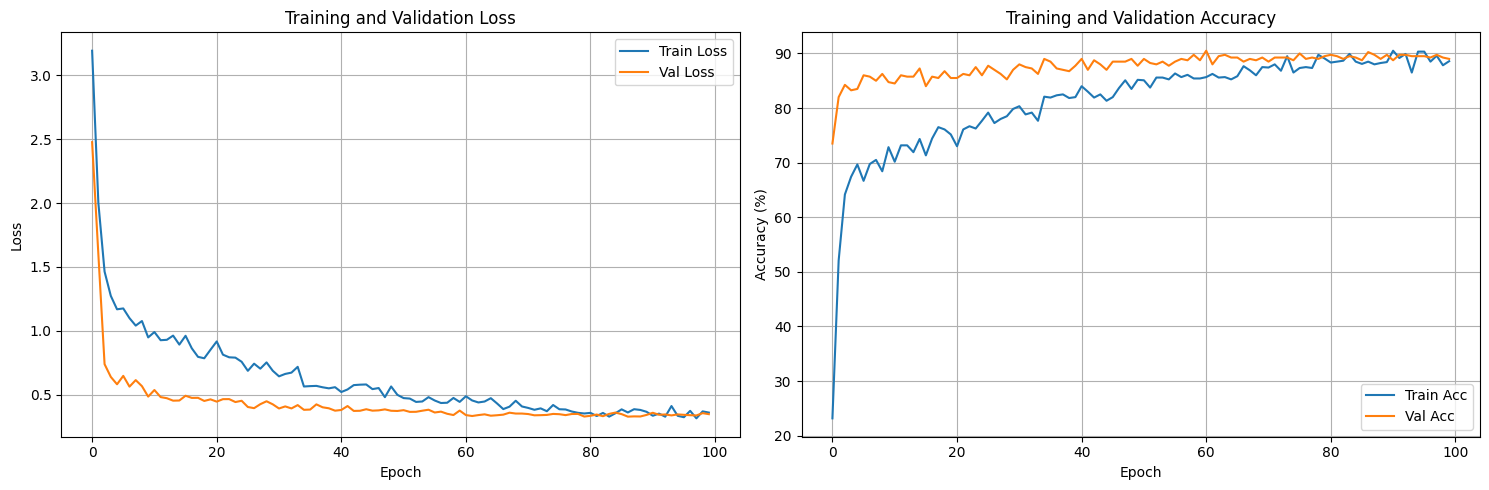

✓ Saved training_history.png


In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot([acc * 100 for acc in history['train_acc']], label='Train Acc')
ax2.plot([acc * 100 for acc in history['val_acc']], label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'), dpi=150)
plt.show()

print("✓ Saved training_history.png")

## 17. Recovery After Disconnect

**Only run this cell if your Colab runtime disconnected after training.**

It loads the best model from the Google Drive checkpoint and recreates the export files.

In [22]:
# ── \U0001f198 RECOVERY CELL: Export trained model from checkpoint after disconnect ──
# If your Colab runtime disconnected after training, run this cell to recreate
# the export files from the checkpoint saved in Google Drive.
#
# This cell:
# 1. Loads the best model from Google Drive checkpoint
# 2. Recreates the export files (model.pt, labels.json, config.json)
# 3. Copies them to Google Drive for download

import os
import json
import torch
import shutil

print("\U0001f504 Recovering trained model from Google Drive checkpoint...\n")

# Check if checkpoint exists
RECOVERY_CHECKPOINT_DIR = "/content/drive/MyDrive/Menial_AI/checkpoints_transfer"
RECOVERY_BEST_MODEL = os.path.join(RECOVERY_CHECKPOINT_DIR, "best_model.pt")

if not os.path.exists(RECOVERY_BEST_MODEL):
    print(f"\u274c Error: Checkpoint not found at {RECOVERY_BEST_MODEL}")
    print("   Your model may not have been saved during training.")
    print("   You'll need to retrain from scratch.")
else:
    print(f"\u2705 Found checkpoint: {RECOVERY_BEST_MODEL}")
    size_mb = os.path.getsize(RECOVERY_BEST_MODEL) / (1024 * 1024)
    print(f"   Size: {size_mb:.2f} MB\n")

    # Recreate the output directory
    recovery_output = "/content/models/transfer_learning"
    os.makedirs(recovery_output, exist_ok=True)

    # 1. Copy best model weights
    print("\U0001f4cb Step 1: Copying model weights...")
    shutil.copy2(RECOVERY_BEST_MODEL, os.path.join(recovery_output, "model.pt"))
    print("   \u2705 model.pt created\n")

    # 2. Recreate labels.json
    print("\U0001f4cb Step 2: Creating labels.json...")
    try:
        label_map = {"num_classes": num_classes, "labels": all_classes}
        with open(os.path.join(recovery_output, "labels.json"), "w") as f:
            json.dump(label_map, f, indent=2)
        print(f"   \u2705 labels.json created ({num_classes} classes)\n")
    except NameError:
        print("   \u26a0\ufe0f  Variables not in memory. Reconstructing from ESC-50...")
        import pandas as pd
        meta = pd.read_csv("/content/data/ESC-50/meta/esc50.csv")
        recovered_labels = sorted(meta['category'].unique().tolist())
        recovered_num_classes = len(recovered_labels)
        label_map = {"num_classes": recovered_num_classes, "labels": recovered_labels}
        with open(os.path.join(recovery_output, "labels.json"), "w") as f:
            json.dump(label_map, f, indent=2)
        print(f"   \u2705 labels.json created ({recovered_num_classes} classes)\n")

    # 3. Recreate config.json
    print("\U0001f4cb Step 3: Creating config.json...")
    try:
        config = {
            "sample_rate": SAMPLE_RATE,
            "duration": DURATION,
            "n_fft": N_FFT,
            "hop_length": HOP_LENGTH,
            "n_mels": N_MELS,
            "f_max": F_MAX,
            "top_db": TOP_DB,
            "model_type": "panns_cnn14" if USE_PRETRAINED else "custom_cnn",
            "n_channels": 1,
            "pretrained_backbone": USE_PRETRAINED,
        }
        with open(os.path.join(recovery_output, "config.json"), "w") as f:
            json.dump(config, f, indent=2)
        print("   \u2705 config.json created\n")
    except NameError as e:
        print(f"   \u26a0\ufe0f  Missing variable: {e}")
        # Use defaults matching the transfer learning config
        config = {
            "sample_rate": 44100,
            "duration": 5,
            "n_fft": 2048,
            "hop_length": 512,
            "n_mels": 64,
            "f_max": 8000,
            "top_db": 80,
            "model_type": "panns_cnn14",
            "n_channels": 1,
            "pretrained_backbone": True,
        }
        with open(os.path.join(recovery_output, "config.json"), "w") as f:
            json.dump(config, f, indent=2)
        print("   \u2705 config.json created (using defaults)\n")

    # 4. Copy to Google Drive
    print("\U0001f4cb Step 4: Copying to Google Drive...")
    drive_models_dir = "/content/drive/MyDrive/Menial_AI/trained_models"
    os.makedirs(drive_models_dir, exist_ok=True)

    for filename in os.listdir(recovery_output):
        src = os.path.join(recovery_output, filename)
        dst = os.path.join(drive_models_dir, filename)
        shutil.copy2(src, dst)
        size_kb = os.path.getsize(dst) / 1024
        print(f"   \u2705 {filename} ({size_kb:.1f} KB)")

    print(f"\n\u2705 Recovery complete! Files saved to Google Drive.")
    print(f"\n\U0001f4e5 Download from: My Drive > Menial_AI > trained_models")

🔄 Recovering trained model from Google Drive checkpoint...

✅ Found checkpoint: /content/drive/MyDrive/Menial_AI/checkpoints_transfer/best_model.pt
   Size: 312.72 MB

📋 Step 1: Copying model weights...
   ✅ model.pt created

📋 Step 2: Creating labels.json...
   ✅ labels.json created (50 classes)

📋 Step 3: Creating config.json...
   ✅ config.json created

📋 Step 4: Copying to Google Drive...
   ✅ model.pt (320228.4 KB)
   ✅ config.json (0.2 KB)
   ✅ labels.json (0.9 KB)
   ✅ training_history.png (120.7 KB)

✅ Recovery complete! Files saved to Google Drive.

📥 Download from: My Drive > Menial_AI > trained_models
